# KV-Cache Serving Analysis

This notebook summarizes real cached-decoding TTFT and TPOT measurements for sequential and fused-parallel execution.


In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA = ROOT / 'results' / 'data'

def load(name):
    with open(DATA / name) as handle:
        return json.load(handle)

def speedups(data):
    groups = {}
    for row in data['rows']:
        groups.setdefault((row['batch_size'], row['prompt_length']), {})[row['mode']] = row
    output = []
    for key, modes in sorted(groups.items()):
        output.append({
            'batch': key[0],
            'prompt': key[1],
            'ttft': modes['sequential']['ttft_seconds'] / modes['parallel_fused']['ttft_seconds'],
            'tpot': modes['sequential']['tpot_seconds'] / modes['parallel_fused']['tpot_seconds'],
        })
    return output


In [2]:
for label, filename in [('ClimbMix', 'climbmix_kv.json'), ('TinyStories', 'tinystories_kv.json')]:
    rows = speedups(load(filename))
    print(label, {
        'mean_ttft_speedup': round(float(np.mean([row['ttft'] for row in rows])), 3),
        'mean_tpot_speedup': round(float(np.mean([row['tpot'] for row in rows])), 3),
        'min_tpot_speedup': round(float(np.min([row['tpot'] for row in rows])), 3),
    })


ClimbMix {'mean_ttft_speedup': 1.222, 'mean_tpot_speedup': 1.256, 'min_tpot_speedup': 1.217}
TinyStories {'mean_ttft_speedup': 1.19, 'mean_tpot_speedup': 1.244, 'min_tpot_speedup': 1.198}


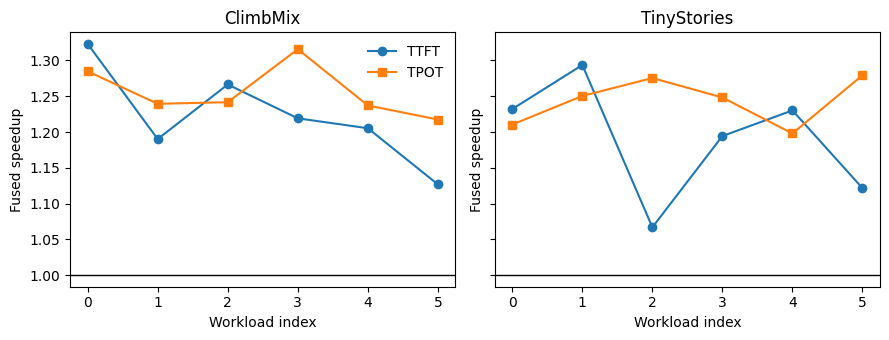

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5), sharey=True)
for axis, (label, filename) in zip(axes, [('ClimbMix', 'climbmix_kv.json'), ('TinyStories', 'tinystories_kv.json')]):
    rows = speedups(load(filename))
    x = np.arange(len(rows))
    axis.plot(x, [row['ttft'] for row in rows], marker='o', label='TTFT')
    axis.plot(x, [row['tpot'] for row in rows], marker='s', label='TPOT')
    axis.axhline(1.0, color='black', linewidth=1)
    axis.set_title(label)
    axis.set_xlabel('Workload index')
    axis.set_ylabel('Fused speedup')
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


## Claim boundary

These are custom PyTorch KV-cache measurements on one L40S, not native vLLM continuous-batching results. The Blackwell work plan describes the remaining vLLM integration and production-style benchmark matrix.
